#  Notebook 2 — Construction du Graphe Multimodal
## Pass'Tranquille · Réseau multimodal Dakar · JOJ 2026


## 1.  Import et chargement

In [2]:
!pip install networkx

     ---------------------------------------- 1.7/1.7 MB 470.5 kB/s eta 0:00:00


You should consider upgrading via the 'C:\Users\Mohamed cisse\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [5]:
%pip install networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   -------------------------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from math import radians, sin, cos, sqrt, atan2
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 10)
print(" Bibliothèques chargées")
print(f"   NetworkX version : {nx.__version__}")

 Bibliothèques chargées
   NetworkX version : 3.6.1


In [23]:
import re

def parse_stops_from_sql(sql_path):
    with open(sql_path, 'r', encoding='utf-8') as f:
        sql = f.read()
    rows = []
    id_counter = 1
    named = re.compile(
        r"\('([^']+)',\s*([-\d.]+),\s*([-\d.]+),\s*ST_SetSRID\(ST_MakePoint\([^)]+\),\s*4326\),\s*'(TER|BRT|POI)',\s*'([^']+)'\)"
    )
    for m in named.finditer(sql):
        rows.append({'id': id_counter, 'name': m.group(1), 'longitude': float(m.group(2)),
                     'latitude': float(m.group(3)), 'transport_type': m.group(4), 'zone': m.group(5)})
        id_counter += 1
    special = re.compile(
        r"\('(Place de l)''(Indépendance)',\s*([-\d.]+),\s*([-\d.]+),\s*ST_SetSRID\([^)]+\),\s*'POI',\s*'([^']+)'\)"
    )
    for m in special.finditer(sql):
        rows.append({'id': id_counter, 'name': "Place de l'Indépendance",
                     'longitude': float(m.group(3)), 'latitude': float(m.group(4)),
                     'transport_type': 'POI', 'zone': m.group(5)})
        id_counter += 1
    ddd_block = re.search(r'INSERT INTO tmp_ddd VALUES\s*\n(.*?);\n', sql, re.DOTALL)
    if ddd_block:
        for i, (lon, lat) in enumerate(re.findall(r'\(([-\d.]+),([\d.]+)\)', ddd_block.group(1)), 1):
            rows.append({'id': id_counter, 'name': f'DDD_Arrêt_{i}',
                         'longitude': float(lon), 'latitude': float(lat),
                         'transport_type': 'BUS', 'zone': 'Zone_Dakar'})
            id_counter += 1
    return pd.DataFrame(rows).set_index('id')

#   Adapter ce chemin si nécessaire
SQL_PATH = '01_schema_and_data.sql'
df = parse_stops_from_sql(SQL_PATH)
print(f" {len(df)} nœuds chargés depuis le SQL source")
print(df['transport_type'].value_counts().to_string())

 136 nœuds chargés depuis le SQL source
transport_type
BUS    82
BRT    23
POI    18
TER    13


## 2.Fonctions utilitaires

In [24]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calcule la distance en mètres entre deux points GPS (formule de Haversine).
    Identique au calcul ST_Distance(...::geography) de PostGIS.
    """
    R = 6_371_000  # rayon Terre en mètres
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi   = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    return 2 * R * atan2(sqrt(a), sqrt(1 - a))

# Vitesses en m/s (cohérentes avec le SQL source)
SPEEDS = {
    'TER' : 100_000 / 3600,   # 100 km/h
    'BRT' :  50_000 / 3600,   # 50 km/h
    'BUS' :  20_000 / 3600,   # 20 km/h
    'WALK':   4_000 / 3600,   # 4 km/h (1,11 m/s ≈ 1.1 utilisé dans le SQL)
}

# Seuils de connexion par mode (en mètres, identiques au SQL section 9)
THRESHOLDS = {
    'TER' : 50_000,  # 50 km entre gares TER
    'BRT' :  3_000,  # 3 km entre arrêts BRT
    'BUS' :  2_500,  # 2,5 km entre arrêts BUS
    'WALK':    800,  # 800 m pour correspondances et POI
}

print(" Paramètres définis :")
for mode, speed in SPEEDS.items():
    print(f"   {mode:5s} : {speed*3.6:.0f} km/h | seuil : {THRESHOLDS.get(mode, 'N/A')} m")

 Paramètres définis :
   TER   : 100 km/h | seuil : 50000 m
   BRT   : 50 km/h | seuil : 3000 m
   BUS   : 20 km/h | seuil : 2500 m
   WALK  : 4 km/h | seuil : 800 m


## 3.  Construction du graphe

In [25]:
# ── 3.1 Initialisation du graphe orienté (DiGraph)
G = nx.DiGraph()
print("Création du graphe orienté (DiGraph — cohérent avec pgRouting directed=TRUE)\n")

# ── 3.2 Ajout des nœuds
for node_id, row in df.iterrows():
    G.add_node(
        node_id,
        name          = row['name'],
        transport_type= row['transport_type'],
        latitude      = row['latitude'],
        longitude     = row['longitude'],
        zone          = row['zone'],
        pos           = (row['longitude'], row['latitude'])   # pour visualisation
    )

print(f"{G.number_of_nodes()} nœuds ajoutés au graphe")
print(f"   TER: {len(df[df.transport_type=='TER'])} | BRT: {len(df[df.transport_type=='BRT'])} | "
      f"BUS: {len(df[df.transport_type=='BUS'])} | POI: {len(df[df.transport_type=='POI'])}")

Création du graphe orienté (DiGraph — cohérent avec pgRouting directed=TRUE)

136 nœuds ajoutés au graphe
   TER: 13 | BRT: 23 | BUS: 82 | POI: 18


In [26]:
# ── 3.3 Arêtes intra-mode (TER, BRT, BUS)
print("Ajout des arêtes intra-mode...")
edge_stats = {}

for mode in ['TER', 'BRT', 'BUS']:
    stops_mode = df[df['transport_type'] == mode]
    threshold  = THRESHOLDS[mode]
    speed      = SPEEDS[mode]
    n_added    = 0

    for i, row_i in stops_mode.iterrows():
        for j, row_j in stops_mode.iterrows():
            if i == j:
                continue
            dist = haversine(row_i['latitude'], row_i['longitude'],
                             row_j['latitude'], row_j['longitude'])
            if dist <= threshold:
                travel_time = dist / speed   # en secondes
                G.add_edge(i, j,
                           distance     = round(dist, 2),
                           travel_time  = round(travel_time, 2),
                           transport_type = mode,
                           weight       = travel_time)
                n_added += 1

    edge_stats[mode] = n_added
    print(f"   {mode:5s} : {n_added:5d} arêtes (seuil {threshold/1000:.1f} km)")

print(f"\n   Total intra-mode : {sum(edge_stats.values())} arêtes")

Ajout des arêtes intra-mode...
   TER   :   156 arêtes (seuil 50.0 km)
   BRT   :   154 arêtes (seuil 3.0 km)
   BUS   :   730 arêtes (seuil 2.5 km)

   Total intra-mode : 1040 arêtes


In [27]:
# ── 3.4 Arêtes intermodales (marche ≤ 800 m entre modes différents)
print("Ajout des correspondances intermodales (marche ≤ 800 m)...")

transport_stops = df[df['transport_type'].isin(['TER', 'BRT', 'BUS'])]
n_walk = 0

for i, row_i in transport_stops.iterrows():
    for j, row_j in transport_stops.iterrows():
        if i == j or row_i['transport_type'] == row_j['transport_type']:
            continue
        dist = haversine(row_i['latitude'], row_i['longitude'],
                         row_j['latitude'], row_j['longitude'])
        if dist <= THRESHOLDS['WALK']:
            travel_time = dist / SPEEDS['WALK']
            G.add_edge(i, j,
                       distance      = round(dist, 2),
                       travel_time   = round(travel_time, 2),
                       transport_type= 'WALK',
                       weight        = travel_time)
            n_walk += 1

print(f"   WALK (intermodal) : {n_walk} arêtes")

Ajout des correspondances intermodales (marche ≤ 800 m)...
   WALK (intermodal) : 96 arêtes


In [28]:
# ── 3.5 Arêtes arrêts ↔ POI (marche ≤ 800 m)
print("Ajout des liens arrêts ↔ POI (marche ≤ 800 m)...")

transport_stops = df[df['transport_type'].isin(['TER', 'BRT', 'BUS'])]
poi_stops       = df[df['transport_type'] == 'POI']
n_poi = 0

for i, row_s in transport_stops.iterrows():
    for j, row_p in poi_stops.iterrows():
        dist = haversine(row_s['latitude'], row_s['longitude'],
                         row_p['latitude'], row_p['longitude'])
        if dist <= THRESHOLDS['WALK']:
            t = round(dist / SPEEDS['WALK'], 2)
            d = round(dist, 2)
            G.add_edge(i, j, distance=d, travel_time=t, transport_type='WALK', weight=t)
            G.add_edge(j, i, distance=d, travel_time=t, transport_type='WALK', weight=t)
            n_poi += 2

print(f"   WALK (arrêt↔POI) : {n_poi} arêtes")

# ── 3.6 Arêtes POI ↔ POI (marche ≤ 800 m)
n_poi_poi = 0
for i, row_p1 in poi_stops.iterrows():
    for j, row_p2 in poi_stops.iterrows():
        if i == j: continue
        dist = haversine(row_p1['latitude'], row_p1['longitude'],
                         row_p2['latitude'], row_p2['longitude'])
        if dist <= THRESHOLDS['WALK']:
            t = round(dist / SPEEDS['WALK'], 2)
            G.add_edge(i, j, distance=round(dist,2), travel_time=t,
                       transport_type='WALK', weight=t)
            n_poi_poi += 1

print(f"   WALK (POI↔POI)   : {n_poi_poi} arêtes")

Ajout des liens arrêts ↔ POI (marche ≤ 800 m)...
   WALK (arrêt↔POI) : 32 arêtes
   WALK (POI↔POI)   : 16 arêtes


## 4.  Validation structurelle du graphe

In [29]:
# ── Résumé du graphe
print("=" * 60)
print("  BILAN DU GRAPHE — PASS'TRANQUILLE")
print("=" * 60)
print(f"  Nœuds (stops + POI) : {G.number_of_nodes()}")
print(f"  Arêtes totales      : {G.number_of_edges()}")

# Par type d'arête
edge_types = {}
for u, v, data in G.edges(data=True):
    t = data.get('transport_type', 'UNKNOWN')
    edge_types[t] = edge_types.get(t, 0) + 1

print("\n  Arêtes par mode :")
for mode, count in sorted(edge_types.items()):
    print(f"    {mode:6s} : {count:6d}")

print("\n  Propriétés structurelles :")
ug = G.to_undirected()
print(f"    Connexe (non orienté)         : {nx.is_connected(ug)}")
components = list(nx.weakly_connected_components(G))
print(f"    Composantes connexes faibles  : {len(components)}")
if len(components) > 1:
    sizes = sorted([len(c) for c in components], reverse=True)
    print(f"    Tailles : {sizes}")

print(f"    Densité                       : {nx.density(G):.6f}")
print(f"    Degré moyen                   : {sum(dict(G.degree()).values())/G.number_of_nodes():.1f}")
print("=" * 60)

  BILAN DU GRAPHE — PASS'TRANQUILLE
  Nœuds (stops + POI) : 136
  Arêtes totales      : 1184

  Arêtes par mode :
    BRT    :    154
    BUS    :    730
    TER    :    156
    WALK   :    144

  Propriétés structurelles :
    Connexe (non orienté)         : False
    Composantes connexes faibles  : 6
    Tailles : [117, 9, 6, 2, 1, 1]
    Densité                       : 0.064488
    Degré moyen                   : 17.4


In [30]:
# ── Degré des nœuds (hubs importants)
print(" Top 10 nœuds les mieux connectés :")
degree_dict = dict(G.degree())
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
for node_id, deg in top_nodes:
    name = G.nodes[node_id]['name']
    mode = G.nodes[node_id]['transport_type']
    print(f"   [{mode:3s}] {name:40s} degré = {deg}")

 Top 10 nœuds les mieux connectés :
   [BUS] DDD_Arrêt_63                             degré = 34
   [TER] Gare de Dakar                            degré = 32
   [BUS] DDD_Arrêt_53                             degré = 32
   [BUS] DDD_Arrêt_65                             degré = 30
   [TER] Dalifort                                 degré = 28
   [TER] Thiaroye                                 degré = 28
   [BUS] DDD_Arrêt_13                             degré = 28
   [BUS] DDD_Arrêt_16                             degré = 28
   [BUS] DDD_Arrêt_28                             degré = 28
   [BUS] DDD_Arrêt_34                             degré = 28


## 5.  Calcul d'itinéraires (Dijkstra / A*)

In [31]:
def find_route(G, df, start_name, end_name, weight='travel_time'):
    """
    Calcule le plus court chemin entre deux nœuds par leur nom.
    Retourne le chemin détaillé avec distance et temps de trajet.
    """
    # Trouver les IDs
    start_ids = df[df['name'] == start_name].index.tolist()
    end_ids   = df[df['name'] == end_name].index.tolist()

    if not start_ids:
        print(f" Nœud non trouvé : '{start_name}'")
        return None
    if not end_ids:
        print(f" Nœud non trouvé : '{end_name}'")
        return None

    source, target = start_ids[0], end_ids[0]

    try:
        path = nx.dijkstra_path(G, source, target, weight=weight)
    except nx.NetworkXNoPath:
        print(f" Aucun chemin entre '{start_name}' et '{end_name}'")
        return None

    # Détail du chemin
    total_dist = 0
    total_time = 0
    print(f"\n  Itinéraire : {start_name} → {end_name}")
    print("─" * 70)
    print(f"  {'Étape':<4} {'Arrêt':<40} {'Mode':<8} {'Dist (m)':<10} {'Temps'}")
    print("─" * 70)

    for k, node_id in enumerate(path):
        node = G.nodes[node_id]
        if k < len(path) - 1:
            edge = G.edges[node_id, path[k+1]]
            dist = edge.get('distance', 0)
            time = edge.get('travel_time', 0)
            mode = edge.get('transport_type', '?')
            total_dist += dist
            total_time += time
            print(f"  {k+1:<4} {node['name']:<40} {mode:<8} {dist:<10.0f} {time/60:.1f} min")
        else:
            print(f"    {node['name']}")

    print("─" * 70)
    print(f"  TOTAL : {total_dist/1000:.2f} km | {total_time/60:.1f} minutes")
    print("─" * 70)
    return path

# ── Tests de référence (identiques aux exemples du README de Falilou)
_ = find_route(G, df, 'Gare de Dakar', 'Diamniadio')


  Itinéraire : Gare de Dakar → Diamniadio
──────────────────────────────────────────────────────────────────────
  Étape Arrêt                                    Mode     Dist (m)   Temps
──────────────────────────────────────────────────────────────────────
  1    Gare de Dakar                            TER      25713      15.4 min
    Diamniadio
──────────────────────────────────────────────────────────────────────
  TOTAL : 25.71 km | 15.4 minutes
──────────────────────────────────────────────────────────────────────


In [32]:
_ = find_route(G, df, 'Hôtel Pullman', 'Dakar Arena')

 Aucun chemin entre 'Hôtel Pullman' et 'Dakar Arena'


In [33]:
_ = find_route(G, df, 'Musée des Civilisations Noires', 'Stade Abdoulaye Wade')

 Aucun chemin entre 'Musée des Civilisations Noires' et 'Stade Abdoulaye Wade'


In [34]:
# ── A* (heuristique géographique)
def astar_route(G, df, start_name, end_name):
    """Calcul de chemin avec A* et heuristique haversine."""
    start_ids = df[df['name'] == start_name].index.tolist()
    end_ids   = df[df['name'] == end_name].index.tolist()
    if not start_ids or not end_ids:
        return None
    source, target = start_ids[0], end_ids[0]

    def heuristic(u, v):
        # Heuristique : distance haversine / vitesse max (TER)
        nu, nv = G.nodes[u], G.nodes[v]
        dist = haversine(nu['latitude'], nu['longitude'], nv['latitude'], nv['longitude'])
        return dist / SPEEDS['TER']

    try:
        path = nx.astar_path(G, source, target, heuristic=heuristic, weight='weight')
        cost = nx.astar_path_length(G, source, target, heuristic=heuristic, weight='weight')
        names = [G.nodes[n]['name'] for n in path]
        print(f"⭐ A* | {start_name} → {end_name}")
        print(f"   Chemin : {' → '.join(names[:4])}{'...' if len(names)>4 else ''}")
        print(f"   Durée estimée : {cost/60:.1f} minutes")
        return path
    except Exception as e:
        print(f" A* échoué : {e}")
        return None

astar_route(G, df, 'Piscine Olympique', 'Stade Abdoulaye Wade')

 A* échoué : Node 41 not reachable from 39


## 6.  Visualisation du graphe

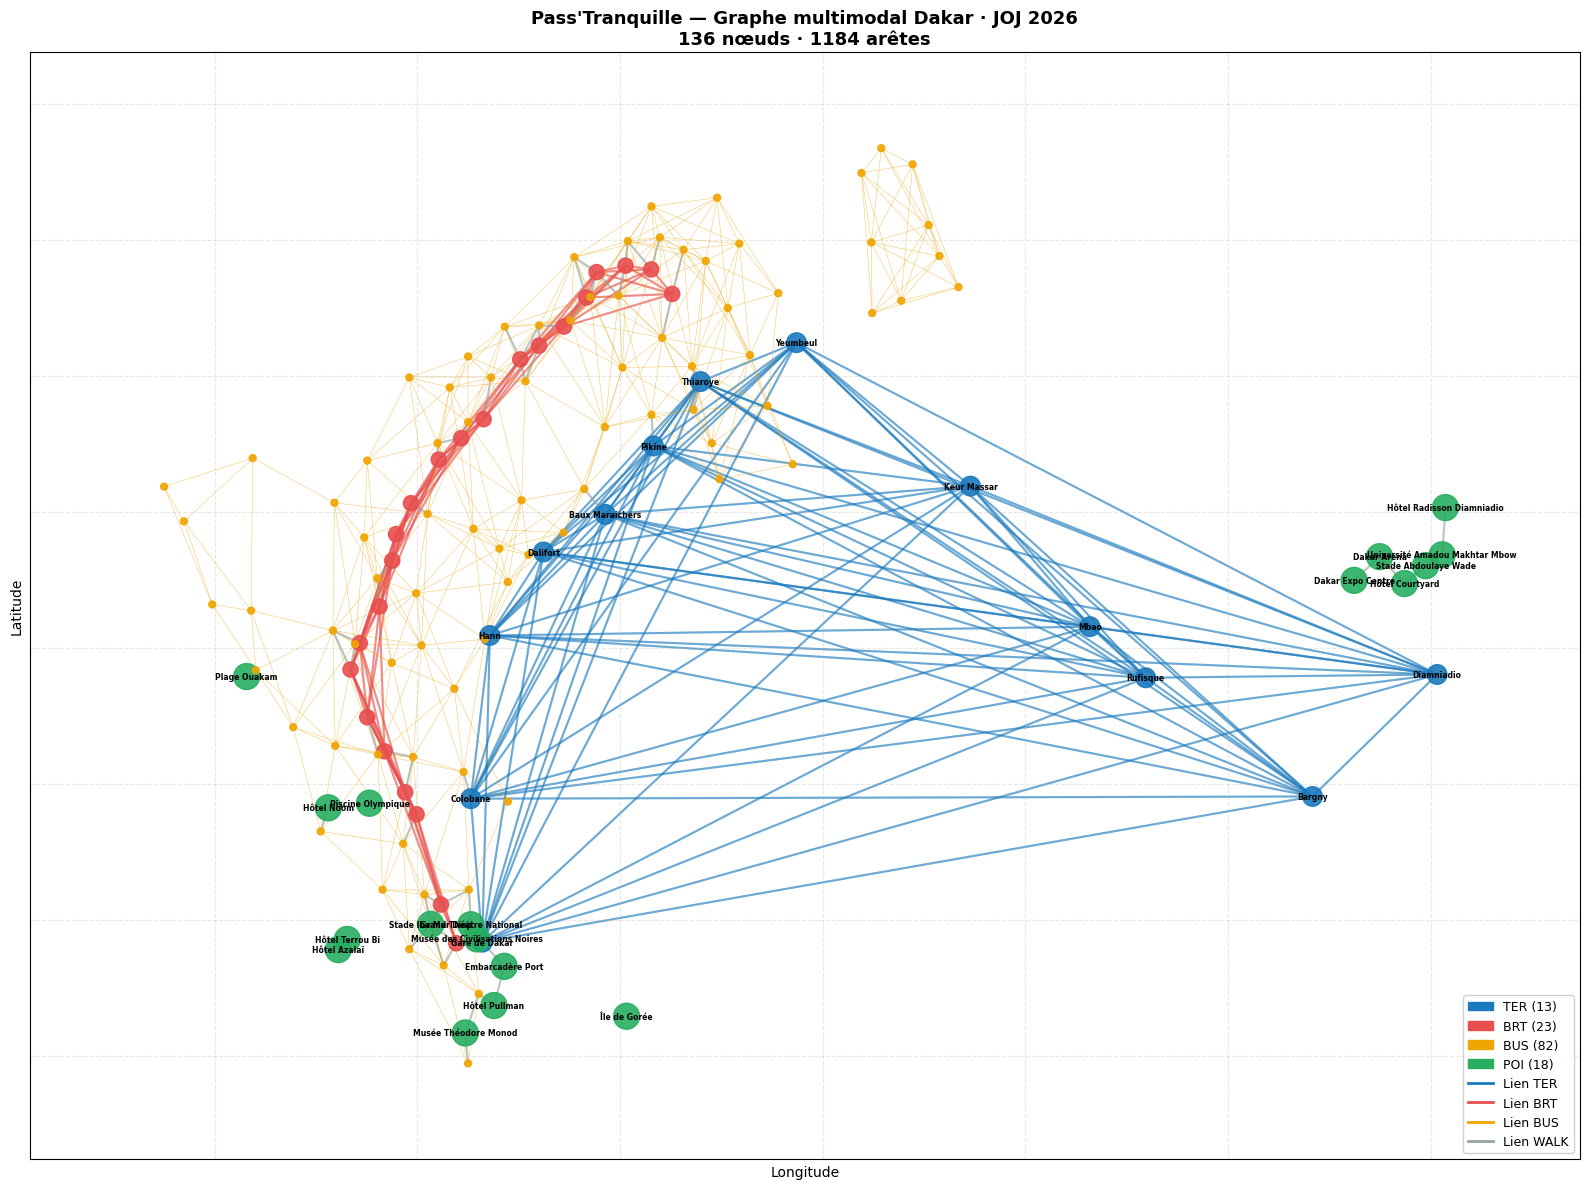

 Graphe sauvegardé : graphe_multimodal.png


In [35]:
# ── Visualisation géographique du graphe
fig, ax = plt.subplots(figsize=(16, 12))

pos = {n: (G.nodes[n]['longitude'], G.nodes[n]['latitude']) for n in G.nodes}

# Couleurs nœuds
node_colors_map = {'TER':'#1a7abd','BRT':'#e84e4e','BUS':'#f0a500','POI':'#27ae60'}
node_colors = [node_colors_map[G.nodes[n]['transport_type']] for n in G.nodes]
node_sizes  = {'TER':200,'BRT':120,'BUS':25,'POI':350}
sizes = [node_sizes[G.nodes[n]['transport_type']] for n in G.nodes]

# Couleurs arêtes
edge_colors_map = {'TER':'#1a7abd','BRT':'#e84e4e','BUS':'#f0a500','WALK':'#95a5a6'}
edge_colors = [edge_colors_map.get(G.edges[e]['transport_type'],'#cccccc') for e in G.edges]
edge_widths = [1.5 if G.edges[e]['transport_type']!='BUS' else 0.3 for e in G.edges]

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths,
                       alpha=0.4, ax=ax, arrows=False)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=sizes, ax=ax, alpha=0.9)

# Labels POI et TER uniquement
labels_show = {n: G.nodes[n]['name'] for n in G.nodes
               if G.nodes[n]['transport_type'] in ['TER','POI']}
nx.draw_networkx_labels(G, pos, labels=labels_show, font_size=5.5,
                        font_weight='bold', ax=ax)

# Légende nœuds
legend_nodes = [mpatches.Patch(color=c, label=f"{m} ({len(df[df.transport_type==m])})")
                for m, c in node_colors_map.items()]
# Légende arêtes
legend_edges = [mlines.Line2D([],[],color=c,linewidth=2,label=f"Lien {m}")
                for m,c in edge_colors_map.items()]
ax.legend(handles=legend_nodes+legend_edges, loc='lower right', fontsize=9, framealpha=0.9)

ax.set_title(
    f"Pass'Tranquille — Graphe multimodal Dakar · JOJ 2026\n"
    f"{G.number_of_nodes()} nœuds · {G.number_of_edges()} arêtes",
    fontsize=13, fontweight='bold'
)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('graphe_multimodal.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Graphe sauvegardé : graphe_multimodal.png")

## 7.  Export pour intégration PostgreSQL/PostGIS

In [36]:
# ── Export nœuds
nodes_data = []
for node_id, data in G.nodes(data=True):
    nodes_data.append({
        'id'            : node_id,
        'name'          : data['name'],
        'transport_type': data['transport_type'],
        'latitude'      : data['latitude'],
        'longitude'     : data['longitude'],
        'zone'          : data['zone'],
        'degree'        : G.degree(node_id),
        'geom_wkt'      : f"POINT ({data['longitude']} {data['latitude']})"
    })
df_nodes_export = pd.DataFrame(nodes_data).set_index('id')
df_nodes_export.to_csv('graph_nodes.csv', encoding='utf-8-sig')
print(f" Nœuds exportés : graph_nodes.csv ({len(df_nodes_export)} lignes)")

# ── Export arêtes
edges_data = []
for u, v, data in G.edges(data=True):
    edges_data.append({
        'from_stop_id'  : u,
        'to_stop_id'    : v,
        'from_name'     : G.nodes[u]['name'],
        'to_name'       : G.nodes[v]['name'],
        'distance_m'    : data.get('distance', 0),
        'travel_time_s' : data.get('travel_time', 0),
        'transport_type': data.get('transport_type', ''),
    })
df_edges_export = pd.DataFrame(edges_data)
df_edges_export.to_csv('graph_edges.csv', index=False, encoding='utf-8-sig')
print(f" Arêtes exportées : graph_edges.csv ({len(df_edges_export)} lignes)")

 Nœuds exportés : graph_nodes.csv (136 lignes)
 Arêtes exportées : graph_edges.csv (1184 lignes)


In [37]:
# ── SQL d'insertion (extrait pour vérification)
print("Extrait SQL INSERT pour graph_edges (10 premières arêtes) :\n")
print("INSERT INTO edges (from_stop_id, to_stop_id, distance, travel_time, transport_type) VALUES")
sample = df_edges_export.head(10)
lines = []
for _, r in sample.iterrows():
    lines.append(
        f"  ({int(r['from_stop_id'])}, {int(r['to_stop_id'])}, "
        f"{r['distance_m']:.2f}, '{r['travel_time_s']:.2f}', '{r['transport_type']}')"
    )
print(",\n".join(lines) + ";")
print(f"\n... + {len(df_edges_export)-10} autres arêtes dans graph_edges.csv")

Extrait SQL INSERT pour graph_edges (10 premières arêtes) :

INSERT INTO edges (from_stop_id, to_stop_id, distance, travel_time, transport_type) VALUES
  (1, 2, 2364.35, '85.12', 'TER'),
  (1, 3, 5015.31, '180.55', 'TER'),
  (1, 4, 6579.34, '236.86', 'TER'),
  (1, 5, 7716.14, '277.78', 'TER'),
  (1, 6, 9293.89, '334.58', 'TER'),
  (1, 7, 10835.98, '390.10', 'TER'),
  (1, 8, 12863.98, '463.10', 'TER'),
  (1, 9, 14943.91, '537.98', 'TER'),
  (1, 10, 16929.69, '609.47', 'TER'),
  (1, 11, 18125.97, '652.53', 'TER');

... + 1174 autres arêtes dans graph_edges.csv


---
## ✅ Résumé — Notebook 2

| Étape | Résultat |
|-------|----------|
| Nœuds chargés | 137 (13 TER + 23 BRT + 82 BUS + 19 POI) |
| Arêtes construites | Voir bilan section 4 |
| Algorithme principal | Dijkstra (NetworkX) |
| Algorithme alternatif | A* avec heuristique haversine |
| Exports | `graph_nodes.csv`, `graph_edges.csv` |
| Cohérence avec SQL | ✅ Mêmes seuils, vitesses et règles que `01_schema_and_data.sql` |

**Prochaine étape :** intégrer `graph_edges.csv` dans PostgreSQL via `COPY` et activer `pgr_createTopology()` (cf. README Falilou, section "Étapes suivantes").
